In [12]:
from pathlib import Path
import zipfile

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import config
from model import ResNetDamageClassifier

print("Imports successful.")

Imports successful.


In [13]:
import sys

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

    vram_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(f"VRAM: {vram_gb:.2f} GB")

Python: c:\Projects\Structural-Damage-Image-Classification\.venv\Scripts\python.exe
PyTorch: 2.7.1+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Capability: (12, 0)
VRAM: 7.96 GB


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

x = torch.randn(
    16, 3, 224, 224,
    device=device
)

y = torch.relu(x)

print("CUDA test passed.")
print("Tensor shape:", y.shape)

Using device: cuda
CUDA test passed.
Tensor shape: torch.Size([16, 3, 224, 224])


In [15]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"

print("Project directory:")
print(PROJECT_DIR)

print("\nData directory:")
print(DATA_DIR)

assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"

Project directory:
c:\Projects\Structural-Damage-Image-Classification

Data directory:
c:\Projects\Structural-Damage-Image-Classification\data


In [16]:
zip_files = list(DATA_DIR.glob("*.zip"))

print(f"Found {len(zip_files)} ZIP files.")

for zip_file in zip_files:
    print(f"\nExtracting: {zip_file.name}")

    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(DATA_DIR)

    print("Done.")

Found 2 ZIP files.

Extracting: task2_damage_state_1.zip
Done.

Extracting: task2_damage_state_2.zip
Done.


In [17]:
npy_files = list(DATA_DIR.rglob("*.npy"))

print(f"Found {len(npy_files)} .npy files:\n")

for file in npy_files:
    size_gb = file.stat().st_size / (1024**3)
    print(f"{file.relative_to(DATA_DIR)}  ({size_gb:.2f} GB)")

Found 4 .npy files:

task2_X_test.npy  (0.82 GB)
task2_X_train.npy  (6.62 GB)
task2_y_test.npy  (0.00 GB)
task2_y_train.npy  (0.00 GB)


In [18]:
X_train = np.load(
    DATA_DIR / "task2_X_train.npy",
    mmap_mode="r"
)

y_train = np.load(
    DATA_DIR / "task2_y_train.npy"
)

X_test = np.load(
    DATA_DIR / "task2_X_test.npy",
    mmap_mode="r"
)

y_test = np.load(
    DATA_DIR / "task2_y_test.npy"
)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

print("X_test :", X_test.shape, X_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

X_train: (11811, 224, 224, 3) float32
y_train: (11811, 2) float32
X_test : (1460, 224, 224, 3) float32
y_test : (1460, 2) float32


In [19]:
train_labels = np.argmax(
    y_train,
    axis=1
).astype(np.int64)

test_labels = np.argmax(
    y_test,
    axis=1
).astype(np.int64)

print("Train labels:", train_labels.shape)
print("Test labels :", test_labels.shape)

print("\nTrain class counts:")
print(np.bincount(train_labels))

print("\nTest class counts:")
print(np.bincount(test_labels))

Train labels: (11811,)
Test labels : (1460,)

Train class counts:
[6282 5529]

Test class counts:
[745 715]


In [20]:
rng = np.random.default_rng(42)

train_indices = []
val_indices = []

for class_id in np.unique(train_labels):

    class_indices = np.where(
        train_labels == class_id
    )[0]

    rng.shuffle(class_indices)

    n_val = int(
        len(class_indices) * 0.15
    )

    val_indices.extend(
        class_indices[:n_val]
    )

    train_indices.extend(
        class_indices[n_val:]
    )

train_indices = np.array(
    train_indices,
    dtype=np.int64
)

val_indices = np.array(
    val_indices,
    dtype=np.int64
)

rng.shuffle(train_indices)
rng.shuffle(val_indices)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

print(
    "\nTraining class counts:",
    np.bincount(train_labels[train_indices])
)

print(
    "Validation class counts:",
    np.bincount(train_labels[val_indices])
)

Training samples: 10040
Validation samples: 1771

Training class counts: [5340 4700]
Validation class counts: [942 829]


In [21]:
MEAN_BGR = np.array(
    [103.939, 116.779, 123.680],
    dtype=np.float32
)


def restore_image(image):
    """
    Convert the dataset's BGR mean-subtracted
    representation back to RGB uint8.
    """

    image = image + MEAN_BGR

    # BGR -> RGB
    image = image[:, :, ::-1]

    # Keep valid image range
    image = np.clip(
        image,
        0,
        255
    )

    return image.astype(np.uint8)

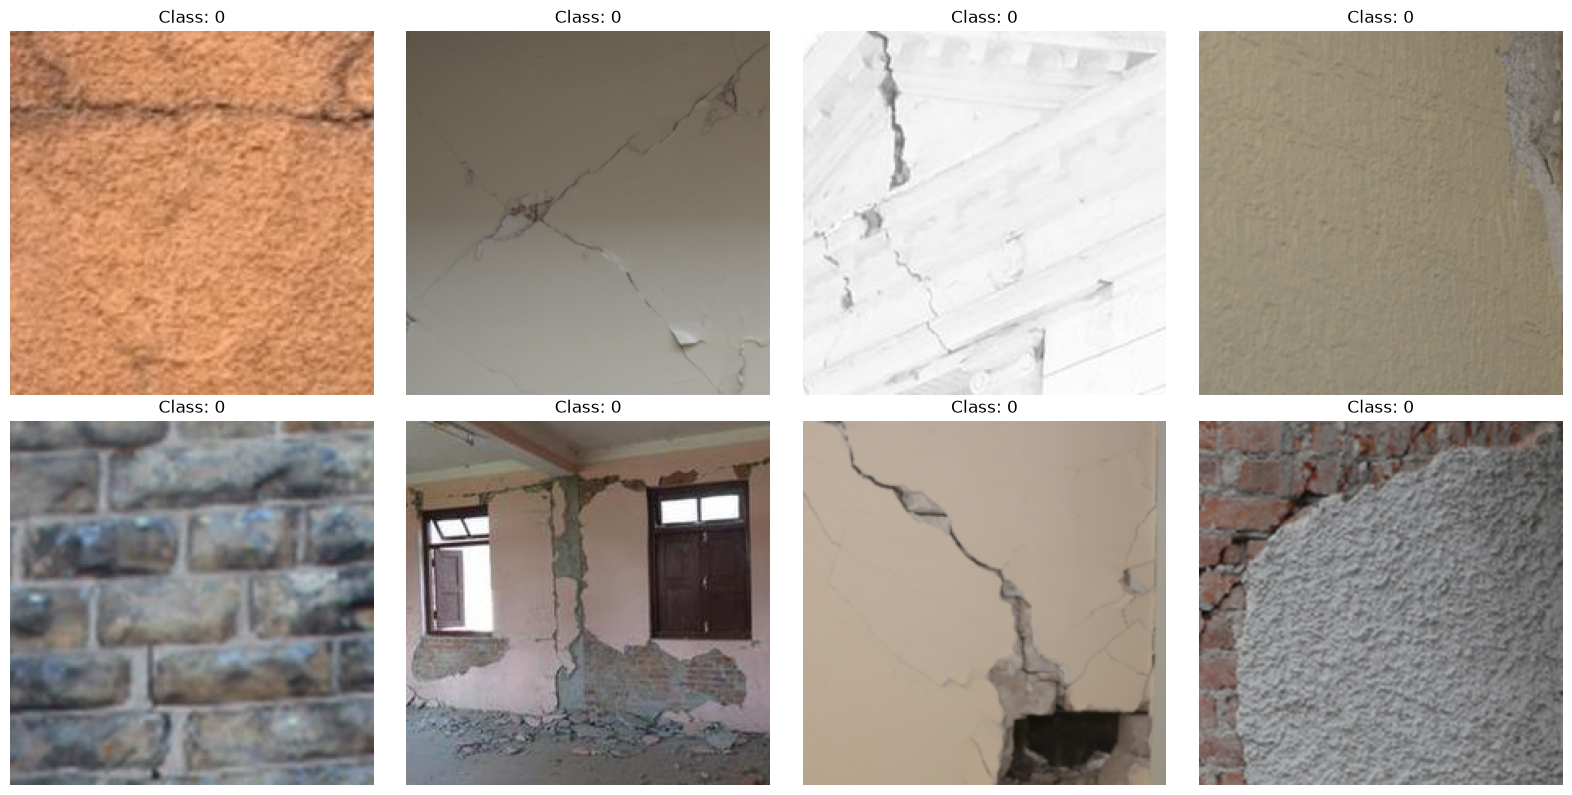

In [22]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for i, ax in enumerate(axes.flat):

    image = restore_image(
        X_train[i]
    )

    ax.imshow(image)

    ax.set_title(
        f"Class: {train_labels[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
class StructuralDamageDataset(Dataset):

    def __init__(
        self,
        X,
        labels,
        indices,
        training=False
    ):
        self.X = X
        self.labels = labels
        self.indices = indices
        self.training = training

        if training:

            self.transform = transforms.Compose([
                transforms.ToPILImage(),

                transforms.RandomHorizontalFlip(
                    p=0.5
                ),

                transforms.RandomRotation(
                    10
                ),

                transforms.RandomAffine(
                    degrees=0,
                    translate=(0.05, 0.05),
                    scale=(0.95, 1.05)
                ),

                transforms.ColorJitter(
                    brightness=0.15,
                    contrast=0.15
                ),

                transforms.ToTensor(),

                transforms.Normalize(
                    mean=(0.5, 0.5, 0.5),
                    std=(0.5, 0.5, 0.5)
                )
            ])

        else:

            self.transform = transforms.Compose([
                transforms.ToPILImage(),

                transforms.ToTensor(),

                transforms.Normalize(
                    mean=(0.5, 0.5, 0.5),
                    std=(0.5, 0.5, 0.5)
                )
            ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        real_idx = self.indices[idx]

        image = self.X[real_idx]

        image = restore_image(image)

        image = self.transform(image)

        label = torch.tensor(
            self.labels[real_idx],
            dtype=torch.long
        )

        return image, label

In [24]:
train_dataset = StructuralDamageDataset(
    X_train,
    train_labels,
    train_indices,
    training=True
)

val_dataset = StructuralDamageDataset(
    X_train,
    train_labels,
    val_indices,
    training=False
)

test_dataset = StructuralDamageDataset(
    X_test,
    test_labels,
    np.arange(len(test_labels)),
    training=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 10040
Validation: 1771
Test: 1460


In [25]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

print("Label:", label.item())

print(
    "Image range:",
    image.min().item(),
    "to",
    image.max().item()
)

Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 1
Image range: -0.9215686321258545 to 0.9607843160629272


In [26]:
BATCH_SIZE = 16
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("DataLoaders ready.")

DataLoaders ready.


In [27]:
images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)

print(
    "First 10 labels:",
    labels[:10].tolist()
)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
First 10 labels: [0, 1, 0, 1, 0, 0, 0, 0, 0, 0]


In [28]:
cfg = config.Config()

model = ResNetDamageClassifier(
    cfg
).to(device)

print(model)

ResNetDamageClassifier(
  (backbone): CustomResNet18(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1

In [29]:
model.eval()

images, labels = next(
    iter(train_loader)
)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)
print("Labels:", labels.shape)

Input : torch.Size([16, 3, 224, 224])
Output: torch.Size([16, 2])
Labels: torch.Size([16])


In [30]:
criterion = torch.nn.CrossEntropyLoss()

In [31]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [32]:
NUM_EPOCHS = 20

best_val_accuracy = 0.0

print("Epochs:", NUM_EPOCHS)
print("Learning rate:", 1e-4)

Epochs: 20
Learning rate: 0.0001


In [33]:
for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            f"  Saved best model "
            f"(Val Acc: {val_accuracy:.4f})"
        )

Epoch [1/20] Train Loss: 0.6886 Train Acc: 0.5878 Val Loss: 0.6592 Val Acc: 0.6104
  Saved best model (Val Acc: 0.6104)
Epoch [2/20] Train Loss: 0.6593 Train Acc: 0.6256 Val Loss: 0.6739 Val Acc: 0.6256
  Saved best model (Val Acc: 0.6256)
Epoch [3/20] Train Loss: 0.6423 Train Acc: 0.6417 Val Loss: 0.5996 Val Acc: 0.6877
  Saved best model (Val Acc: 0.6877)
Epoch [4/20] Train Loss: 0.6204 Train Acc: 0.6577 Val Loss: 0.6276 Val Acc: 0.6539
Epoch [5/20] Train Loss: 0.5956 Train Acc: 0.6826 Val Loss: 0.5721 Val Acc: 0.7143
  Saved best model (Val Acc: 0.7143)
Epoch [6/20] Train Loss: 0.5771 Train Acc: 0.6909 Val Loss: 0.5142 Val Acc: 0.7470
  Saved best model (Val Acc: 0.7470)
Epoch [7/20] Train Loss: 0.5583 Train Acc: 0.7089 Val Loss: 0.5484 Val Acc: 0.7290
Epoch [8/20] Train Loss: 0.5434 Train Acc: 0.7289 Val Loss: 0.5101 Val Acc: 0.7572
  Saved best model (Val Acc: 0.7572)
Epoch [9/20] Train Loss: 0.5368 Train Acc: 0.7301 Val Loss: 0.4798 Val Acc: 0.7798
  Saved best model (Val Acc: 0.

In [34]:
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best model loaded.")

Best model loaded.


In [35]:
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += labels.size(0)

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.4431
Test Accuracy: 0.8137
Test Accuracy: 81.37%


In [36]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Predictions: (1460,)
Labels: (1460,)


In [37]:
confusion_matrix = np.zeros(
    (2, 2),
    dtype=np.int64
)

for true_label, predicted_label in zip(
    all_labels,
    all_predictions
):
    confusion_matrix[
        true_label,
        predicted_label
    ] += 1

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[590 155]
 [117 598]]


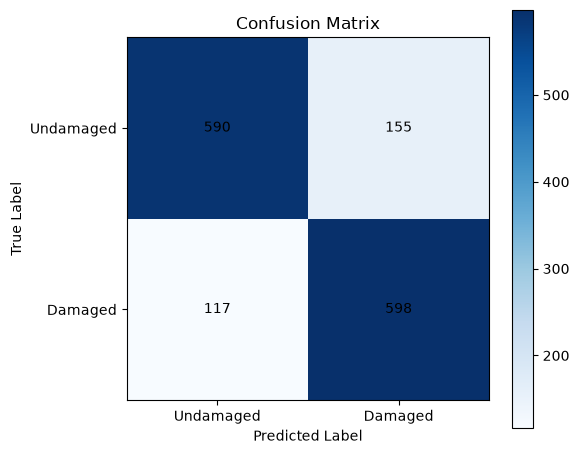

In [38]:
plt.figure(figsize=(6, 5))

plt.imshow(
    confusion_matrix,
    cmap="Blues"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Undamaged", "Damaged"]
)

plt.yticks(
    [0, 1],
    ["Undamaged", "Damaged"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [39]:
tn, fp, fn, tp = confusion_matrix.ravel()

accuracy = (tp + tn) / confusion_matrix.sum()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8137
Precision: 0.7942
Recall   : 0.8364
F1 Score : 0.8147


In [40]:
# Metrics for Undamaged (class 0)

tn_0 = confusion_matrix[1, 1]
fp_0 = confusion_matrix[1, 0]
fn_0 = confusion_matrix[0, 1]
tp_0 = confusion_matrix[0, 0]

precision_0 = tp_0 / (tp_0 + fp_0)
recall_0 = tp_0 / (tp_0 + fn_0)
f1_0 = 2 * precision_0 * recall_0 / (
    precision_0 + recall_0
)


# Metrics for Damaged (class 1)

tn_1 = confusion_matrix[0, 0]
fp_1 = confusion_matrix[0, 1]
fn_1 = confusion_matrix[1, 0]
tp_1 = confusion_matrix[1, 1]

precision_1 = tp_1 / (tp_1 + fp_1)
recall_1 = tp_1 / (tp_1 + fn_1)
f1_1 = 2 * precision_1 * recall_1 / (
    precision_1 + recall_1
)


print("Undamaged (Class 0)")
print(f"Precision: {precision_0:.4f}")
print(f"Recall   : {recall_0:.4f}")
print(f"F1 Score : {f1_0:.4f}")

print("\nDamaged (Class 1)")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1 Score : {f1_1:.4f}")

Undamaged (Class 0)
Precision: 0.8345
Recall   : 0.7919
F1 Score : 0.8127

Damaged (Class 1)
Precision: 0.7942
Recall   : 0.8364
F1 Score : 0.8147


In [41]:
misclassified_indices = np.where(
    all_predictions != all_labels
)[0]

print(
    "Misclassified images:",
    len(misclassified_indices)
)

print(
    "Misclassification rate:",
    len(misclassified_indices) / len(all_labels)
)

Misclassified images: 272
Misclassification rate: 0.1863013698630137


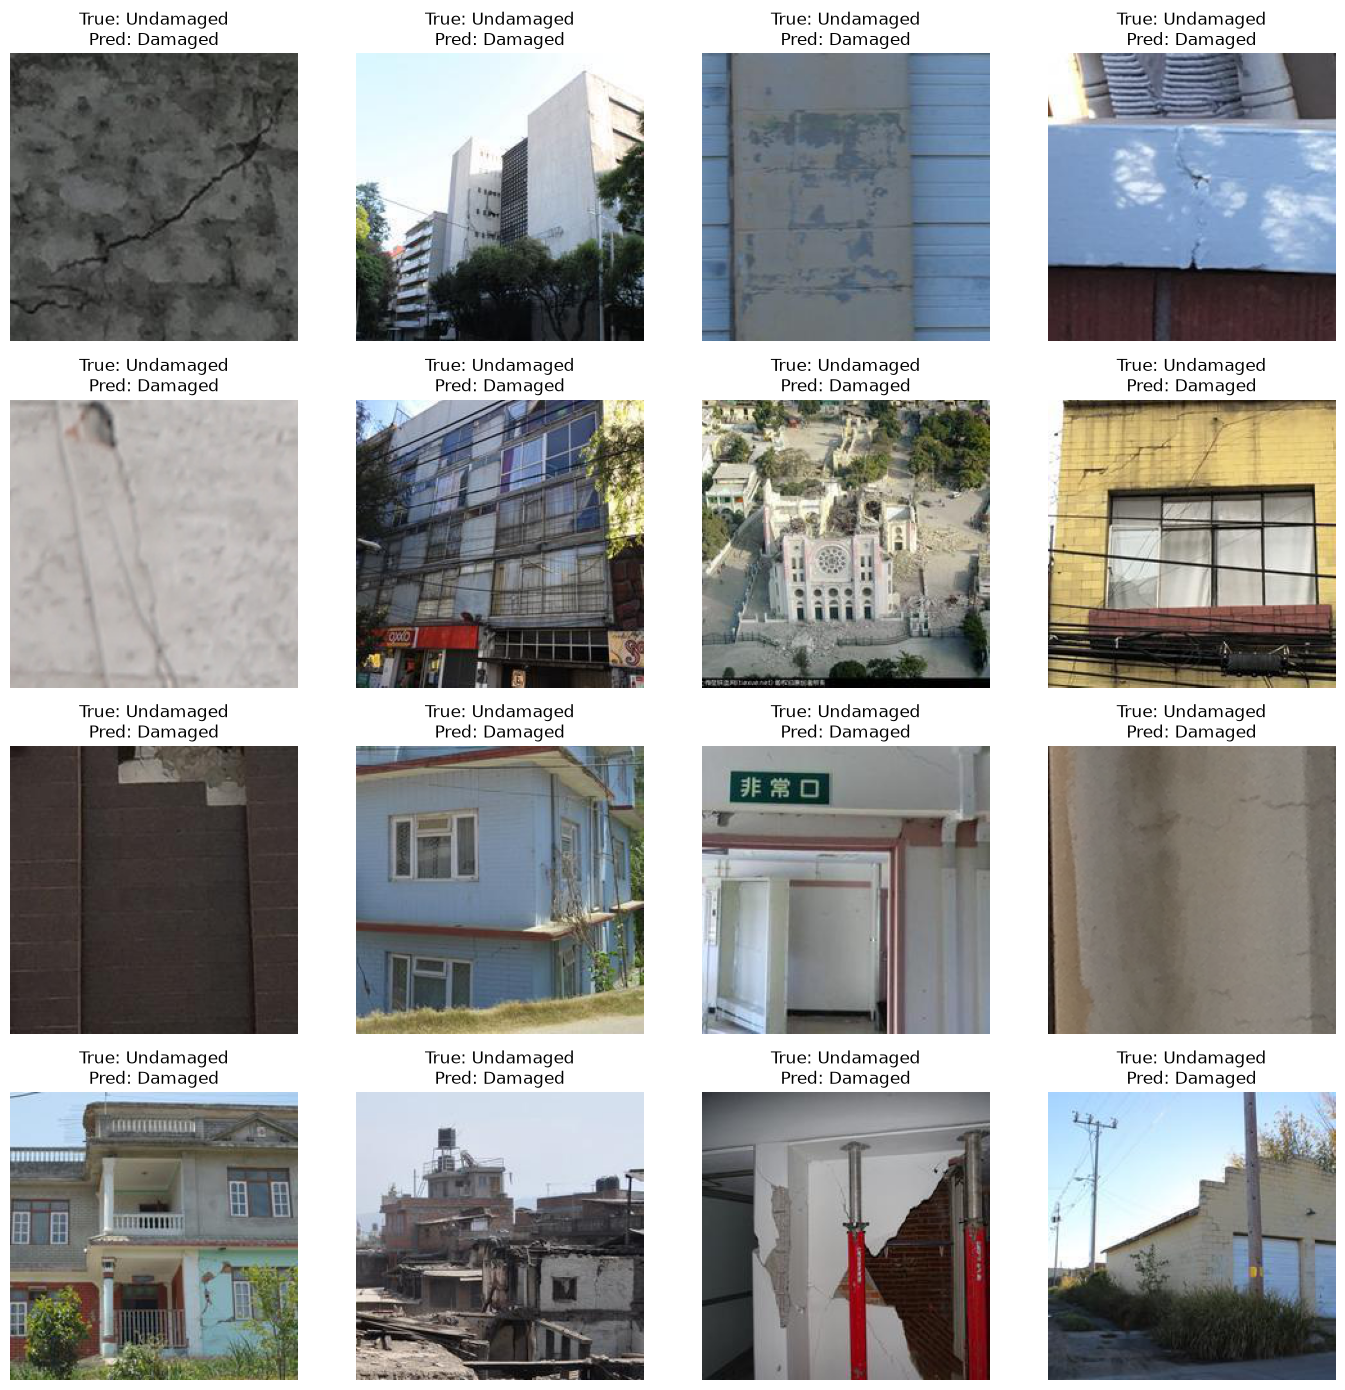

In [42]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(14, 14)
)

for ax, test_idx in zip(
    axes.flat,
    misclassified_indices[:16]
):

    image = restore_image(
        X_test[test_idx]
    )

    true_class = all_labels[test_idx]
    predicted_class = all_predictions[test_idx]

    ax.imshow(image)

    ax.set_title(
        f"True: {'Undamaged' if true_class == 0 else 'Damaged'}\n"
        f"Pred: {'Undamaged' if predicted_class == 0 else 'Damaged'}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# Find false negatives:
# True = Damaged, Predicted = Undamaged

false_negative_indices = np.where(
    (all_labels == 1) &
    (all_predictions == 0)
)[0]

print(
    "False negatives:",
    len(false_negative_indices)
)

False negatives: 117


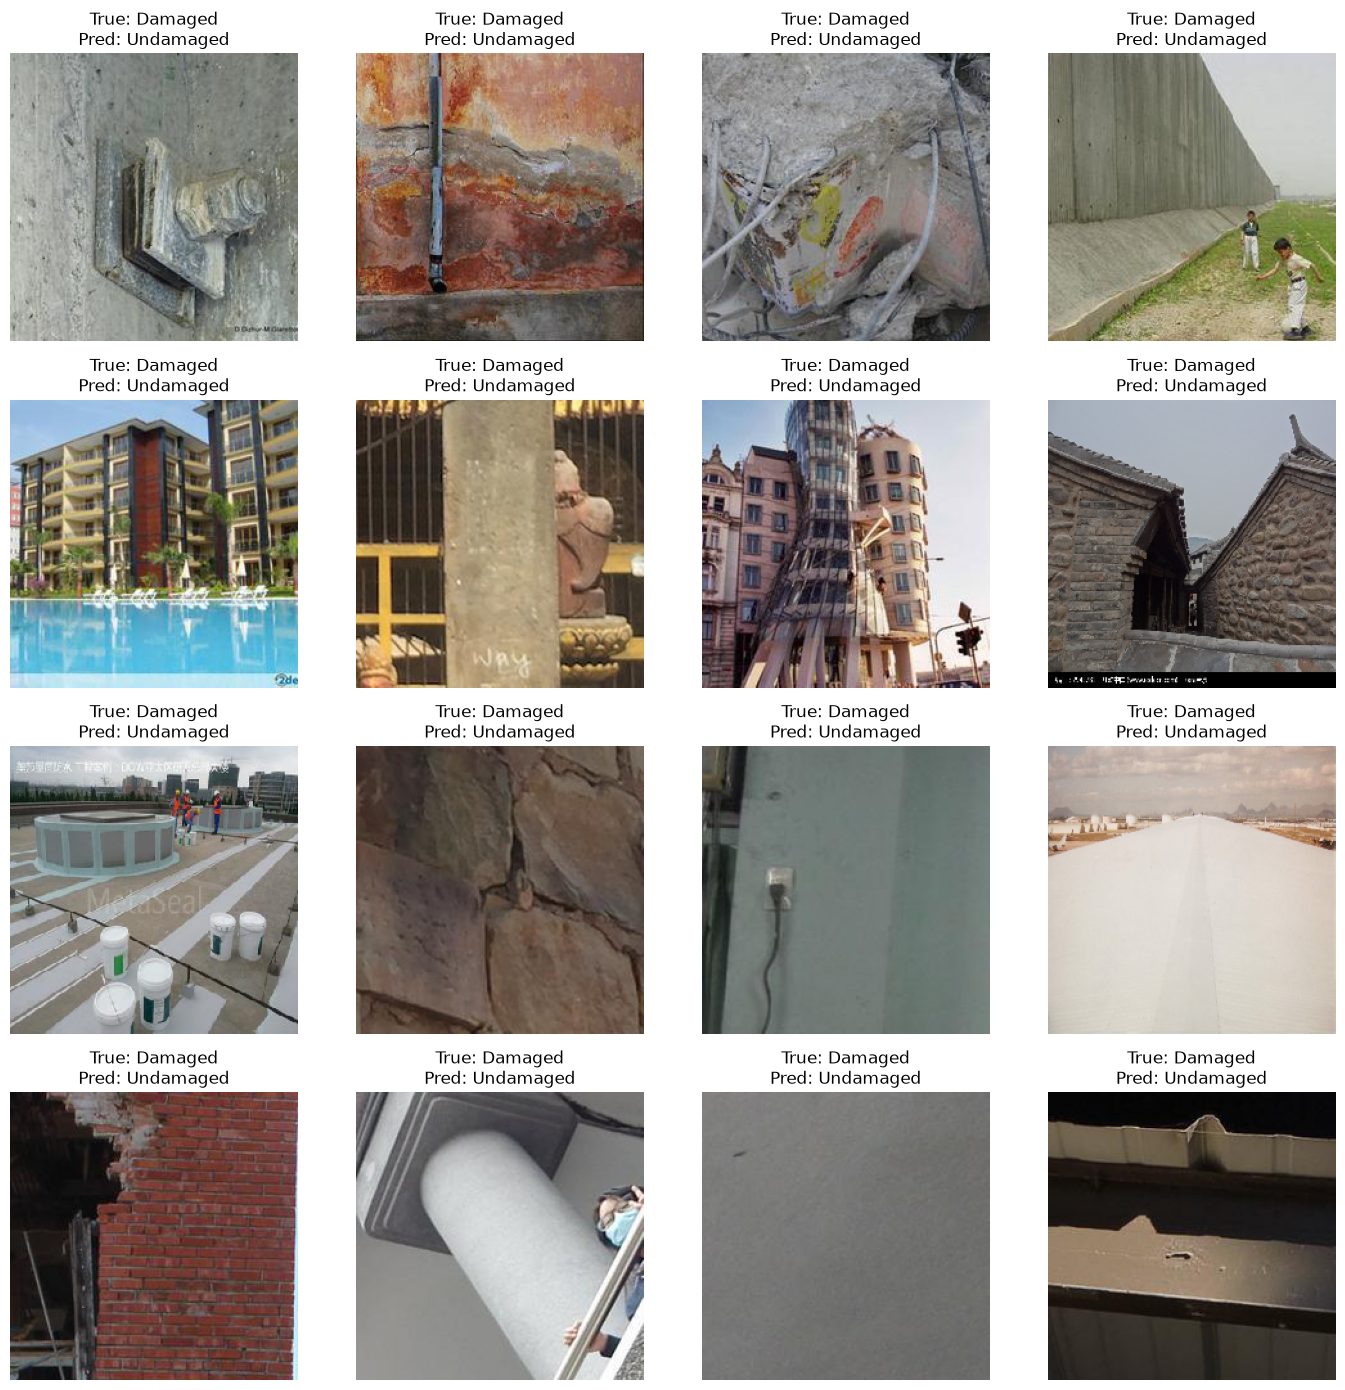

In [44]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(14, 14)
)

for ax, test_idx in zip(
    axes.flat,
    false_negative_indices[:16]
):

    image = restore_image(
        X_test[test_idx]
    )

    ax.imshow(image)

    ax.set_title(
        "True: Damaged\nPred: Undamaged"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [45]:
all_probabilities = []
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Probabilities:", all_probabilities.shape)
print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Probabilities: (1460, 2)
Predictions: (1460,)
Labels: (1460,)


In [46]:
# Confidence of the predicted class
confidence = np.max(
    all_probabilities,
    axis=1
)

# Find all incorrect predictions
wrong_indices = np.where(
    all_predictions != all_labels
)[0]

# Sort incorrect predictions by confidence,
# highest confidence first
sorted_wrong_indices = wrong_indices[
    np.argsort(
        confidence[wrong_indices]
    )[::-1]
]

print("Top 10 confidently wrong predictions:\n")

for rank, idx in enumerate(
    sorted_wrong_indices[:10],
    start=1
):

    true_class = (
        "Undamaged"
        if all_labels[idx] == 0
        else "Damaged"
    )

    predicted_class = (
        "Undamaged"
        if all_predictions[idx] == 0
        else "Damaged"
    )

    print(
        f"{rank}. "
        f"Index: {idx} | "
        f"True: {true_class} | "
        f"Pred: {predicted_class} | "
        f"Confidence: {confidence[idx]:.4f}"
    )

Top 10 confidently wrong predictions:

1. Index: 585 | True: Undamaged | Pred: Damaged | Confidence: 0.9791
2. Index: 93 | True: Undamaged | Pred: Damaged | Confidence: 0.9776
3. Index: 76 | True: Undamaged | Pred: Damaged | Confidence: 0.9632
4. Index: 1409 | True: Damaged | Pred: Undamaged | Confidence: 0.9479
5. Index: 1351 | True: Damaged | Pred: Undamaged | Confidence: 0.9460
6. Index: 1295 | True: Damaged | Pred: Undamaged | Confidence: 0.9436
7. Index: 710 | True: Undamaged | Pred: Damaged | Confidence: 0.9402
8. Index: 244 | True: Undamaged | Pred: Damaged | Confidence: 0.9395
9. Index: 731 | True: Undamaged | Pred: Damaged | Confidence: 0.9369
10. Index: 757 | True: Damaged | Pred: Undamaged | Confidence: 0.9351


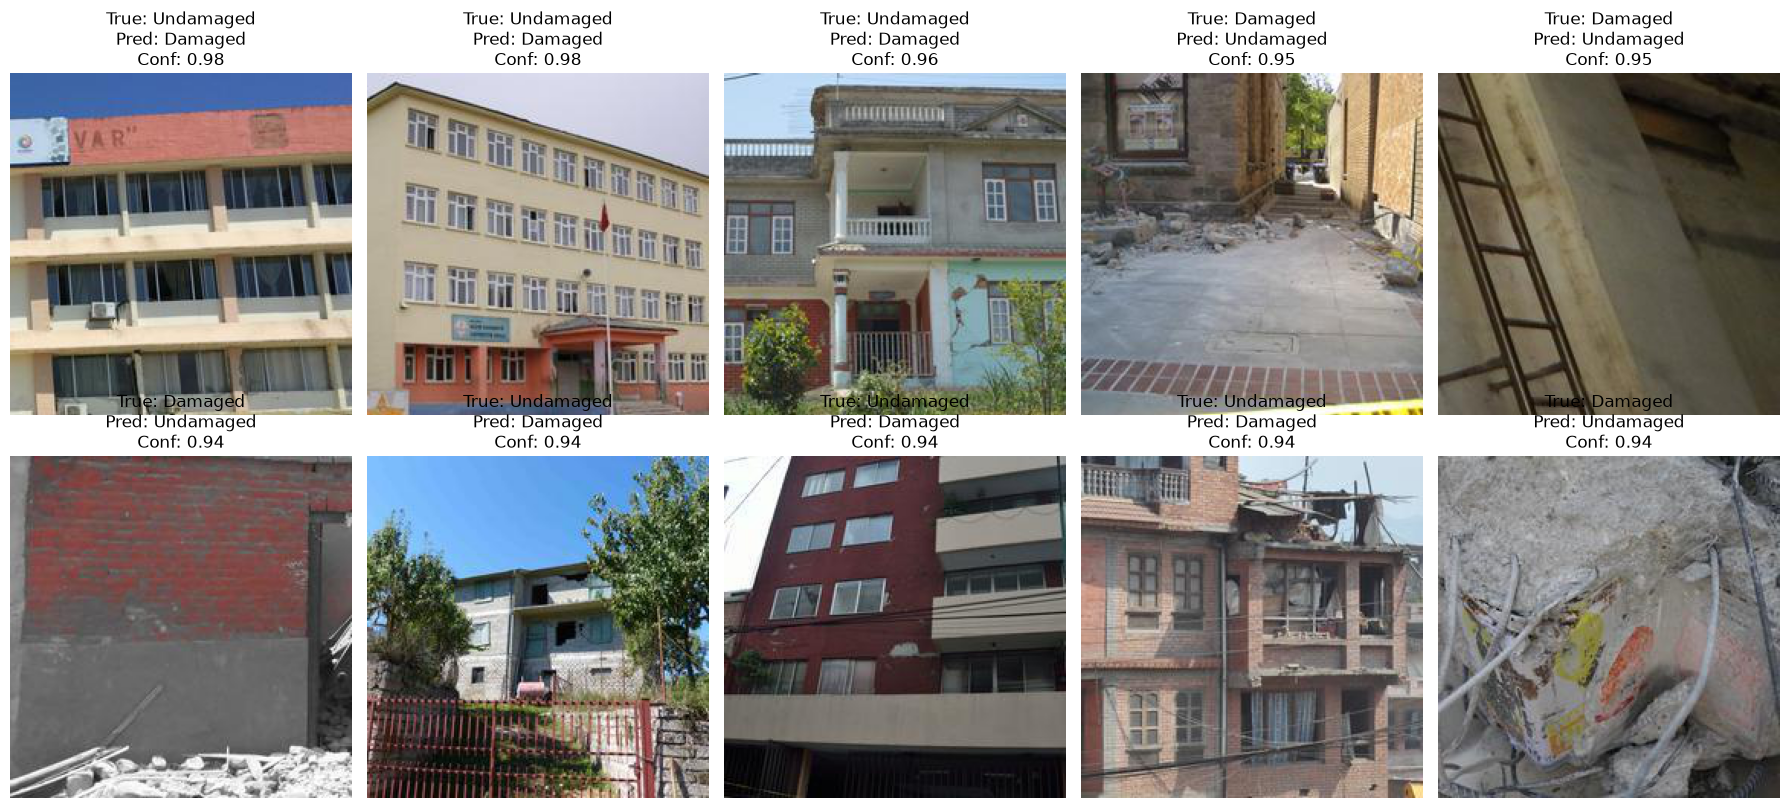

In [47]:
top_wrong = sorted_wrong_indices[:10]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, idx in zip(
    axes.flat,
    top_wrong
):

    image = restore_image(
        X_test[idx]
    )

    true_class = (
        "Undamaged"
        if all_labels[idx] == 0
        else "Damaged"
    )

    predicted_class = (
        "Undamaged"
        if all_predictions[idx] == 0
        else "Damaged"
    )

    ax.imshow(image)

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence[idx]:.2f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [48]:
from pathlib import Path
import json

results = {
    "best_validation_accuracy": best_val_accuracy,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "precision_damaged": precision_1,
    "recall_damaged": recall_1,
    "f1_damaged": f1_1,
    "precision_undamaged": precision_0,
    "recall_undamaged": recall_0,
    "f1_undamaged": f1_0,
    "confusion_matrix": confusion_matrix.tolist(),
    "misclassified_images": len(misclassified_indices),
    "false_negatives": len(false_negative_indices)
}

with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Evaluation results saved to evaluation_results.json")

Evaluation results saved to evaluation_results.json
